In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.27767328/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# c1 - First look

Enter measurements for species

In [14]:
logN_dict = {'HI':'14.08, -0.06, +0.06',
            'HeI':'<12.7',
            'CII':'<13.1',
            'CIII':'13.0, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.1',
            'NIII':'<12.8',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.85, -0.08, +0.08',
            'OIV':'14.44, -0.05, +0.05',
            'OV':'14.22, -0.05, +0.05',
            'OVI':'14.64, -0.07, +0.09',
            'NeV':'14.18, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',
            'NeVIII':'<13.3',
            'MgX':'<13.4',
            'AlII':'<10.7',
            'AlIII':'<11.2',
            'SiII':'<13.9',
            'SiIII':'<11.7',
            'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',
            'SVI':'<12.9'}

Try out a solution

In [15]:
logN_HI_test = 14.08
log_hdens_test = -3.67
log_metals_test = -0.29

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

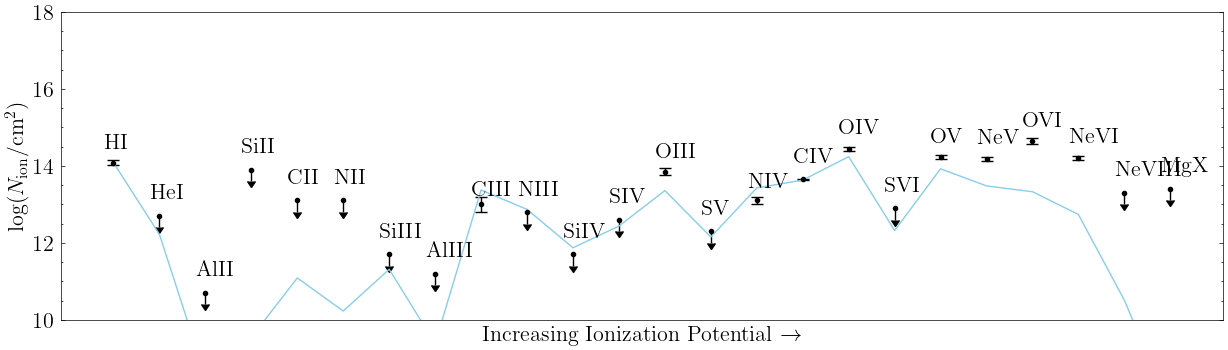

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# c1 - Single phase solution

In [19]:
gen_logN_ratio_str(logN_dict['OIV'], logN_dict['OIII'])

'0.59, -0.09, 0.09'

In [20]:
logN_ratio_dict = {'OIV/OIII': '0.59, -0.09, 0.09'}
                   #'SIV/OIII': '<-1.2, 0.2',
                   #'SV/OIII': '<-1.5, 0.2'}

(-2.2, 2.5)

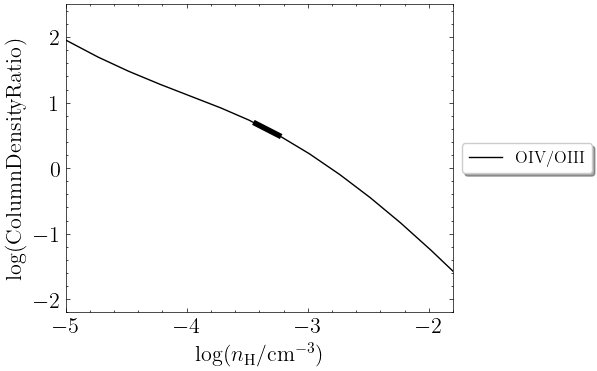

In [21]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [22]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [26]:
pos = np.array(-3.3) + 1e-4 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [27]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [28]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [00:42<00:00, 11.68it/s]


In [29]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_op.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_op.csv')

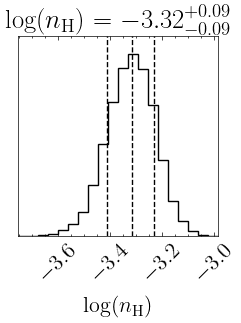

In [33]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [34]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [35]:
logN_offset = 13.85-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate C/O ratio

In [36]:
logN_CIV_obs = np.random.normal(loc=13.65, scale=0.01, size=len(flat_samples_hdens))

In [37]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [38]:
get_quantiles(C_O_dist)

0.0 -0.11 0.11


Calculate the N/O ratio

In [39]:
logN_NIV_obs = np.random.normal(loc=13.1, scale=0.1, size=len(flat_samples_hdens))

In [40]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [41]:
get_quantiles(N_O_dist)

-0.5 -0.16 0.16


Get yields

In [42]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.85 -0.02 0.01


Plot models

In [43]:
logN_dict = {#'HI':'14.08, -0.06, +0.06',
            'HeI':'<12.7',
            'CII':'<13.1',
            'CIII':'13.0, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.1',
            'NIII':'<12.8',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.85, -0.08, +0.08',
            'OIV':'14.44, -0.05, +0.05',
            'OV':'14.22, -0.05, +0.05',
            'OVI':'14.64, -0.07, +0.09',
            'NeV':'14.18, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.3',
            #'MgX':'<13.4',
            'AlII':'<10.7',
            'AlIII':'<11.2',
            'SiII':'<13.9',
            'SiIII':'<11.7',
            'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',
            'SVI':'<12.9'}

In [44]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

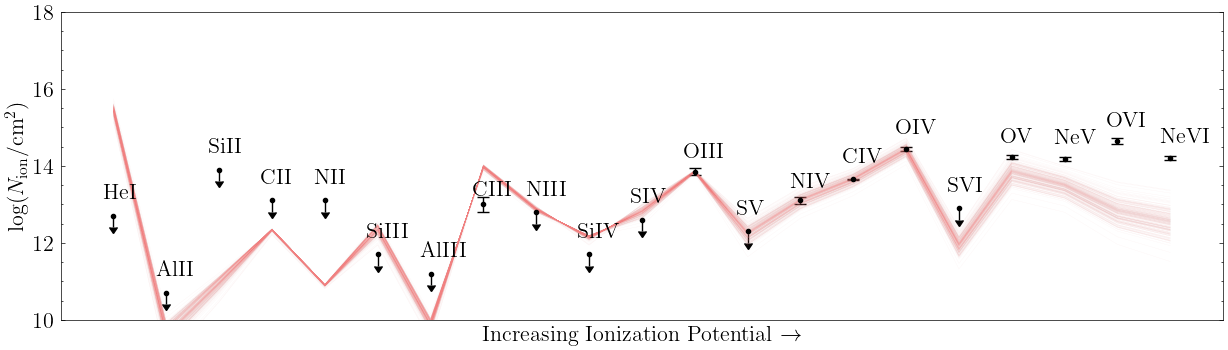

In [45]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist), 'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

# c1 - Two-phase solution: low density phase

In [46]:
logN_dict = {#'HI':'14.08, -0.06, +0.06',
            #'HeI':'<12.7',
            #'CII':'<13.1',
            #'CIII':'13.0, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.1',
            #'NIII':'<12.8',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'<13.85',
            'OIV':'14.44, -0.05, +0.05',
            'OV':'14.22, -0.05, +0.05',
            'OVI':'<14.64',}
            #'NeV':'14.18, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.3',
            #'MgX':'<13.4',
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<13.9',
            #'SiIII':'<11.7',
            #'SiIV':'<11.7',
            #'SIV':'<12.6',
            #'SV':'<12.3',
            #'SVI':'<12.9'}

Get column density ratios

In [49]:
gen_logN_ratio_str(logN_dict['OVI'], logN_dict['OIV'])

'<0.20, 0.15'

In [50]:
logN_ratio_dict = {'OV/OIV': '-0.22, -0.07, 0.07',
                  'OIII/OIV': '<-0.6, 0.2',
                  'OVI/OIV': '<0.2, 0.2'}

Generate predicted column density ratios

(-5.0, 2.0)

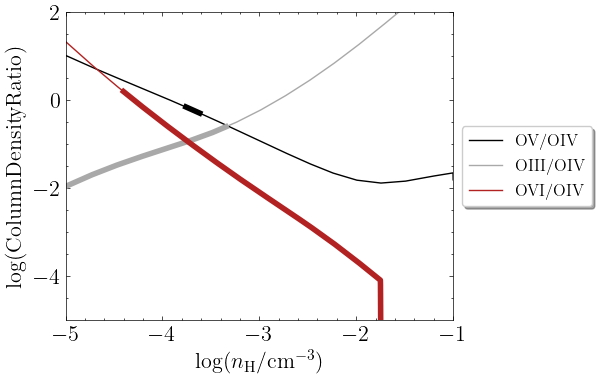

In [52]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1)
ax.set_ylim(-5, 2)

In [53]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [56]:
pos = np.array(-3.7) + 1e-6 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [57]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [58]:
#sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [01:54<00:00,  4.36it/s]


In [68]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo_c1.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c1.csv')

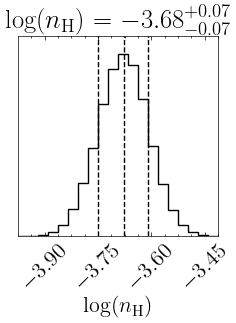

In [69]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [70]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [71]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

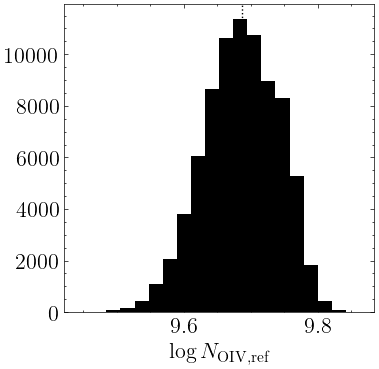

In [72]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

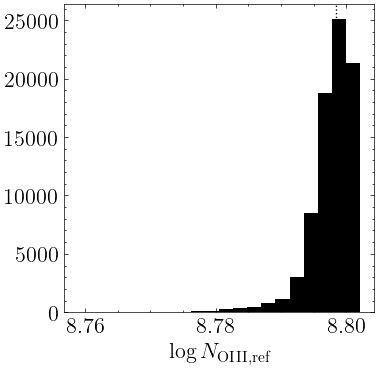

In [73]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

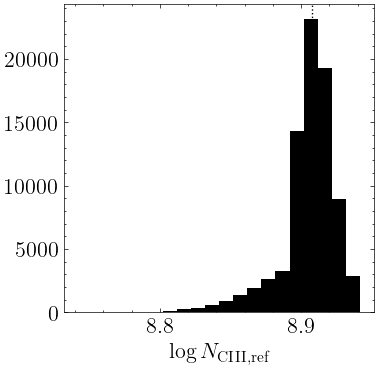

In [74]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [75]:
logN_offset = 14.44-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [76]:
logN_offset

4.7535027062599475

Calculate the C/O ratio

In [77]:
logN_CIV_obs = np.random.normal(loc=13.65, scale=0.01, size=len(flat_samples_hdens))

In [78]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [79]:
get_quantiles(C_O_dist)

0.01 -0.04 0.05


Compute N/O ratio

In [80]:
logN_NIV_obs = np.random.normal(loc=13.1, scale=0.1, size=len(flat_samples_hdens))

In [81]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [82]:
get_quantiles(N_O_dist)

-0.57 -0.12 0.12


Get yields

In [83]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.55 -0.0 0.0


In [84]:
get_quantiles(logN_offset+np.median(C_O_dist)+species_logN_interp['O+2'](grid_points_hdens))

13.57 -0.0 0.0


Plot models

In [91]:
logN_dict = {#'HI':'14.08, -0.06, +0.06',
            #'HeI':'<12.7',
            #'CII':'<13.1',
            'CIII':'13.0, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.1',
            'NIII':'<12.8',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.85, -0.08, +0.08',
            'OIV':'14.44, -0.05, +0.05',
            'OV':'14.22, -0.05, +0.05',
            'OVI':'14.64, -0.07, +0.09',
            'NeV':'14.18, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',}
            #'NeVIII':'<13.3',
            #'MgX':'<13.4',
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<13.9',
            #'SiIII':'<11.7',
            #'SiIV':'<11.7',
            #'SIV':'<12.6',
            #'SV':'<12.3',
            #'SVI':'<12.9'}

In [92]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

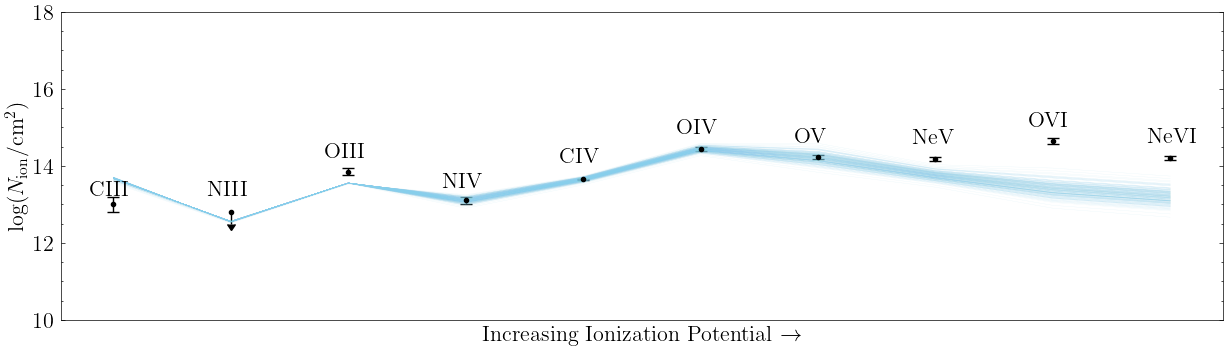

In [93]:
fig, ax = plot_column_densities_obs(logN_dict)

#ax.errorbar(x=1, y=14.06, yerr=[[0.06],[0.04]], color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C': np.median(C_O_dist), 
                                        'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for CIII

In [91]:
logN_CIII_tot = np.random.normal(loc=13.0, scale=0.2, size=1000)
logN_CIII_lo_dens = np.random.normal(loc=13.2, scale=0.1, size=1000)
logN_CIII_hi_dens = np.log10(10**logN_CIII_tot - 10**logN_CIII_lo_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_2131/2641168875.py:3: RuntimeWarning: invalid value encountered in log10
  logN_CIII_hi_dens = np.log10(10**logN_CIII_tot - 10**logN_CIII_lo_dens)


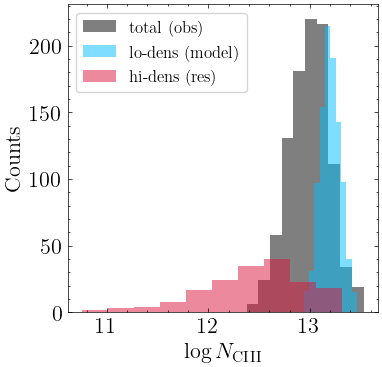

In [92]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_CIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_CIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_CIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{CIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [93]:
logN_CIII_hi_dens_clean = logN_CIII_hi_dens[~np.isnan(logN_CIII_hi_dens)]

In [94]:
get_quantiles(logN_CIII_hi_dens_clean)

12.51 -0.59 0.39


In [95]:
np.percentile(logN_CIII_hi_dens_clean, 100*cdf_3sig)

13.303384686098262

Calculate residual for OIII

In [96]:
logN_OIII_tot = np.random.normal(loc=13.82, scale=0.09, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.2, scale=0.1, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

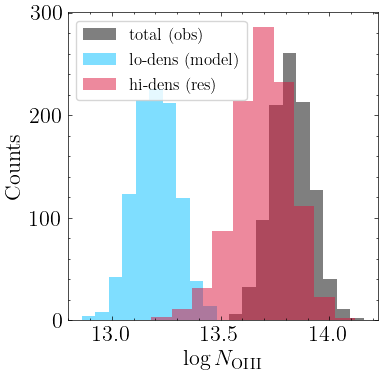

In [97]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [98]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [99]:
get_quantiles(logN_OIII_hi_dens_clean)

13.7 -0.13 0.13


# c1 - Two-phase solution: high density phase

In [100]:
logN_dict = {#'HI':'14.08, -0.06, +0.06',
            #'HeI':'<12.8',
            #'CII':'<13.1',
            #'CIII':'<13.5',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.1',
            #'NIII':'<12.8',
            #'NIV':'13.0, -0.1, +0.1',
            'OIII':'13.7, -0.1, +0.1',
            'OIV':'<14.43',
            #'NeV':'14.21, -0.05, +0.05',
            #'NeVI':'14.20, -0.05, +0.05',
            #'NeVIII':'<13.3',
            #'MgX':'<13.3',
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            'SiII': '<12.0',#'<13.9', # Took upper limit from Sankar
            'SiIII':'<11.7',
            'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',}
            #'SVI':'<12.8',
            #'FeII':'<11.8',}

In [101]:
gen_logN_ratio_str(logN_dict['SiII'], logN_dict['OIII'])

'<-1.70, 0.17'

In [102]:
logN_ratio_dict = {'SiII/OIII': '<-1.7, 0.2',
                   #'SiIII/OIII': '<-2.0, 0.2',
                   #'SiIV/OIII': '<-2.0, 0.2',
                   'SIV/OIII': '<-1.1, 0.2',
                   'SV/OIII': '<-1.4, 0.2',
                   'OIV/OIII': '<0.7, 0.2'
                  }

(-5.0, 5.0)

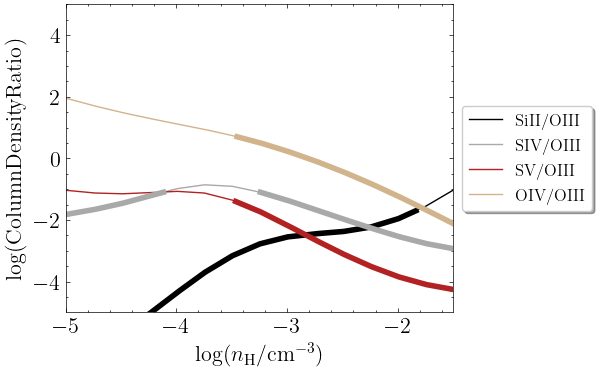

In [103]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [105]:
#pos = np.array(-2.5) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [106]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [107]:
#sampler.run_mcmc(pos, 500, progress=True);

In [109]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_hi_c1.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c1.csv')

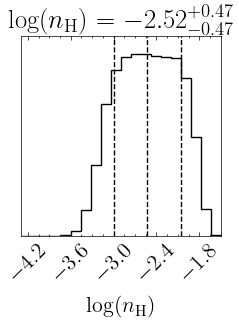

In [110]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [111]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [112]:
logN_offset = 13.7-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [113]:
logN_offset

5.25911364493351

Get yields

In [114]:
get_quantiles(logN_offset+species_logN_interp['C+2'](grid_points_hdens))

13.49 -0.54 0.46


In [115]:
13.5-13.5

0.0

Plot models

In [116]:
logN_dict = {#'HI':'14.08, -0.06, +0.06',
            #'HeI':'<12.8',
            #'CII':'<13.1',
            #'CIII':'<13.5',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.1',
            #'NIII':'<12.8',
            #'NIV':'13.0, -0.1, +0.1',
            'OIII':'13.7, -0.1, +0.1',
            'OIV':'<14.43',
            #'NeV':'14.21, -0.05, +0.05',
            #'NeVI':'14.20, -0.05, +0.05',
            #'NeVIII':'<13.3',
            #'MgX':'<13.3',
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            'SiII': '<12.0',#'<13.9', # Took upper limit from Sankar
            #'SiIII':'<11.7',
            #'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',}
            #'SVI':'<12.8',
            #'FeII':'<11.8',}

In [117]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

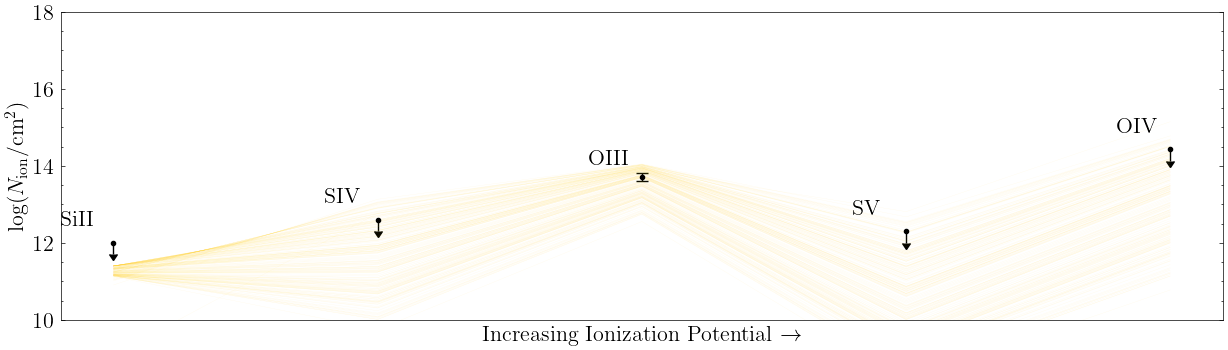

In [118]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [119]:
get_cloud_size(14.08, -2.5, species_logN_interp)

0.009705432748548671

# c2 - First look

Enter measurements for species

In [120]:
logN_dict = {'HI':'13.98, -0.07, +0.07',
            'HeI':'<12.8',
            'CII':'<13.1',
            'CIII':'<12.4',
            'CIV':'13.41, -0.01, +0.01',
            'NII':'<13.1',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OIII':'<13.1',
            'OIV':'14.21, -0.05, +0.05',
            'NeV':'<13.1',
            'NeVI':'13.9, -0.1, +0.1',
            'NeVIII':'<13.3',
            'MgX':'<13.3',
            'AlII':'<10.7',
            'AlIII':'<11.1',
            'SiII':'<13.9',
            'SiIII':'<11.7',
            'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',
            'SVI':'<12.8',
            'FeII':'<11.7'}

Try out a solution

In [121]:
logN_HI_test = 13.98
log_hdens_test = -3.67
log_metals_test = -0.29

In [122]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

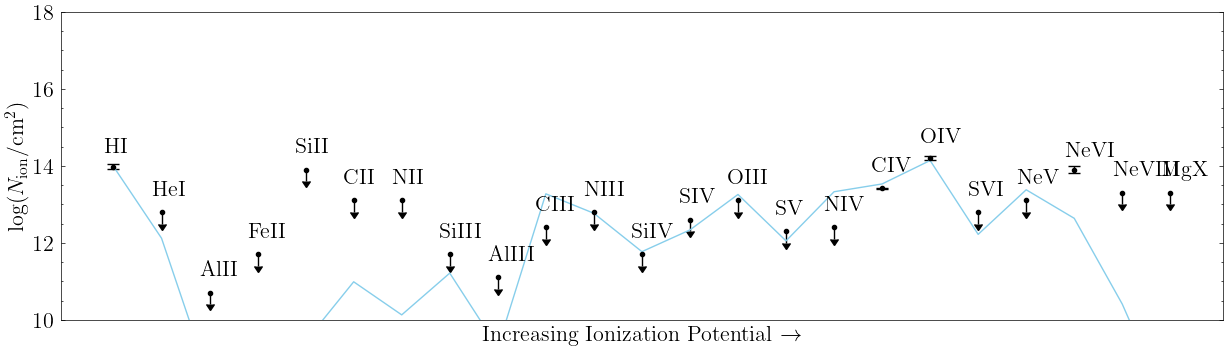

In [123]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# c2 - Two-phase solution: low density phase

In [124]:
logN_dict = {#'HI':'13.98, -0.07, +0.07',
            #'HeI':'<12.8',
            #'CII':'<13.1',
            'CIII':'<12.4',
            'CIV':'13.41, -0.01, +0.01',
            #'NII':'<13.1',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OIII':'<13.1',
            'OIV':'14.21, -0.05, +0.05',
            'NeV':'<13.1',
            'NeVI':'<13.9',
            'NeVIII':'<13.3',
            'MgX':'<13.3',
            #'AlII':'<10.7',
            #'AlIII':'<11.1',
            #'SiII':'<13.9',
            #'SiIII':'<11.7',
            #'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',
            'SVI':'<12.8',}
            #'FeII':'<11.7'}

Get column density ratios

In [125]:
gen_logN_ratio_str(logN_dict['SVI'], logN_dict['OIV'])

'<-1.41, 0.15'

In [126]:
logN_ratio_dict = {#'CIII/CIV': '<-1.0, 0.1',
                   'OIII/OIV': '<-1.1, 0.2',
                   #'NeV/OIV': '<-1.1, 0.2',
                   'NeVI/OIV': '<-0.3, 0.2',
                   'NeVIII/OIV': '<-0.9, 0.2',
                   'MgX/OIV': '<-0.9, 0.2',
                   'SIV/OIV': '<-1.6, 0.2',}
                   #'SV/OIV': '<-1.9, 0.2',}
                   #'SVI/OIV': '<-1.4, 0.2'}

(-2.2, 2.0)

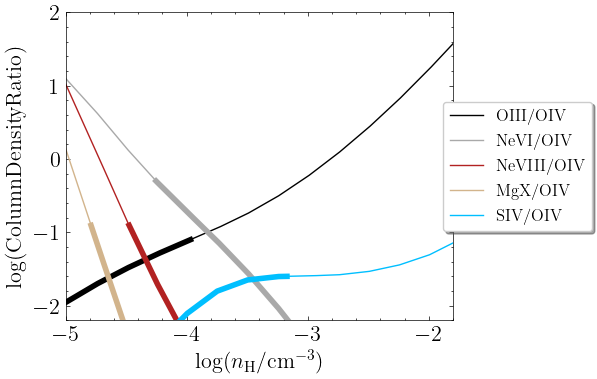

In [127]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2)

In [131]:
#pos = np.array(-4.2) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [132]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [133]:
#sampler.run_mcmc(pos, 500, progress=True);

In [134]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo_c2.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c2.csv')

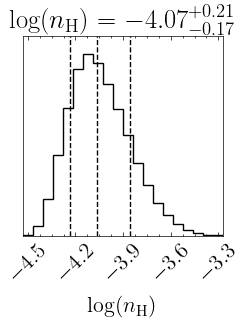

In [135]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [136]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [137]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

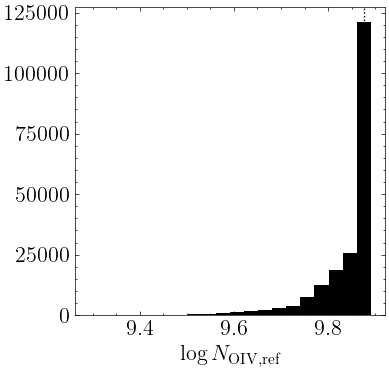

In [138]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [139]:
logN_offset = 14.21-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [140]:
logN_offset

4.332971820141491

Calculate the C/O ratio

In [141]:
logN_CIV_obs = np.random.normal(loc=13.41, scale=0.01, size=len(flat_samples_hdens))

In [142]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [143]:
get_quantiles(C_O_dist)

0.12 -0.02 0.03


Plot models

In [144]:
logN_dict = {#'HI':'13.98, -0.07, +0.07',
            #'HeI':'<12.8',
            #'CII':'<13.1',
            'CIII':'<12.4',
            'CIV':'13.41, -0.01, +0.01',
            #'NII':'<13.1',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OIII':'<13.1',
            'OIV':'14.21, -0.05, +0.05',
            'NeV':'<13.1',
            'NeVI':'<13.9',
            'NeVIII':'<13.3',
            'MgX':'<13.3',
            #'AlII':'<10.7',
            #'AlIII':'<11.1',
            #'SiII':'<13.9',
            #'SiIII':'<11.7',
            #'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',
            'SVI':'<12.8',}
            #'FeII':'<11.7'}

In [145]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

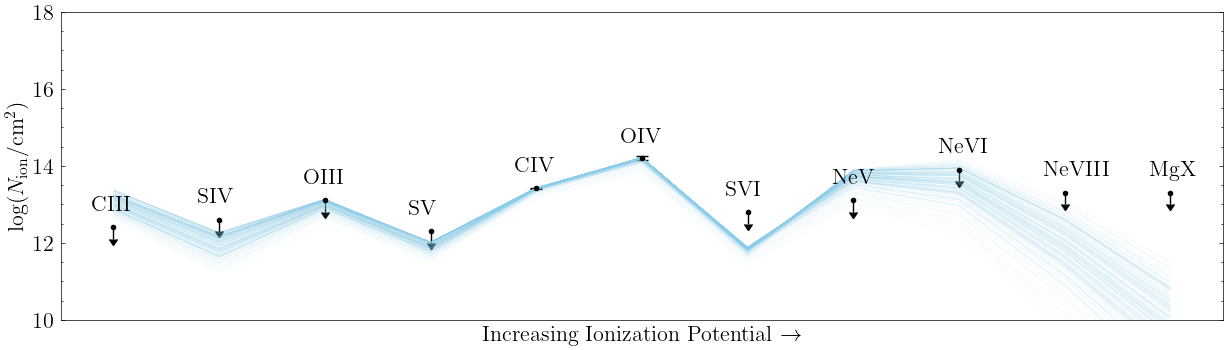

In [146]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)